# CS-GY 6313 / CUSP-GX 6006: Data Visualization - Spring '25
# Homework #2

In [ ]:
!pip install pandas
!pip install geopandas
!pip install geoplot
!pip install pyogrio

In [1]:
import pandas as pd
import geopandas
import geoplot
import matplotlib.pyplot as plt

import numpy as np

## Data Pre-Processing (3/15 points)

In [2]:
# ----------------------- #
# DO NOT MODIFY THIS CODE #
# ----------------------- #

trips_df = pd.read_csv('./datasets/202007-divvy-tripdata.csv')
community_df = geopandas.read_file('./datasets/chicago-community-areas.geojson')
stations_df = pd.read_csv('./datasets/station-locations.csv')

### Bike Trip Pre-processing (1 point)

In [3]:
trips_df.isnull().sum()

ride_id                 0
rideable_type           0
started_at              0
ended_at                0
start_station_name    149
start_station_id      152
end_station_name      967
end_station_id        969
start_lat               0
start_lng               0
end_lat               770
end_lng               770
member_casual           0
dtype: int64

In [4]:
trips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 551480 entries, 0 to 551479
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             551480 non-null  object 
 1   rideable_type       551480 non-null  object 
 2   started_at          551480 non-null  object 
 3   ended_at            551480 non-null  object 
 4   start_station_name  551331 non-null  object 
 5   start_station_id    551328 non-null  float64
 6   end_station_name    550513 non-null  object 
 7   end_station_id      550511 non-null  float64
 8   start_lat           551480 non-null  float64
 9   start_lng           551480 non-null  float64
 10  end_lat             550710 non-null  float64
 11  end_lng             550710 non-null  float64
 12  member_casual       551480 non-null  object 
dtypes: float64(6), object(7)
memory usage: 54.7+ MB


In [5]:
"""
TODO:
Within the bike trip data that we loaded (`trips_df`), get rid of missing (`NaN`)
start and end station ids, and convert those columns to integer columns.
Make sure the modified dataframe is referenced as `trips_pr_df`.
"""
trips_pr_df = trips_df.copy()
trips_pr_df = trips_pr_df.dropna(axis=0,subset=['end_station_id','start_station_id'])
trips_pr_df['start_station_id']=trips_pr_df['start_station_id'].astype(int)
trips_pr_df['end_station_id']=trips_pr_df['end_station_id'].astype(int)



In [6]:
trips_pr_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 550425 entries, 0 to 551479
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ride_id             550425 non-null  object 
 1   rideable_type       550425 non-null  object 
 2   started_at          550425 non-null  object 
 3   ended_at            550425 non-null  object 
 4   start_station_name  550425 non-null  object 
 5   start_station_id    550425 non-null  int64  
 6   end_station_name    550425 non-null  object 
 7   end_station_id      550425 non-null  int64  
 8   start_lat           550425 non-null  float64
 9   start_lng           550425 non-null  float64
 10  end_lat             550425 non-null  float64
 11  end_lng             550425 non-null  float64
 12  member_casual       550425 non-null  object 
dtypes: float64(4), int64(2), object(7)
memory usage: 58.8+ MB


### Community Areas Pre-processing (1 point)

In [7]:
"""
TODO:
Within the geojson data for the Chicago community areas (`community_df`), rename the
column `area_numbe` to `area_number`, and convert that column to an integer
column. Make sure to reference the modified geojson data as `community_pr`.
"""

community_pr_df = community_df.copy()
community_pr_df['area_number'] = community_pr_df['area_numbe']
community_pr_df = community_pr_df.drop(axis=1, columns="area_numbe")
community_pr_df['area_number'] = community_pr_df['area_number'].astype(int)


In [8]:
community_pr_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   community    77 non-null     object  
 1   area         77 non-null     object  
 2   shape_area   77 non-null     object  
 3   perimeter    77 non-null     object  
 4   area_num_1   77 non-null     object  
 5   comarea_id   77 non-null     object  
 6   comarea      77 non-null     object  
 7   shape_len    77 non-null     object  
 8   geometry     77 non-null     geometry
 9   area_number  77 non-null     int64   
dtypes: geometry(1), int64(1), object(8)
memory usage: 6.1+ KB


### Stations Pre-processing (1 point)

In [9]:
stations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691 entries, 0 to 690
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   has_kiosk                             691 non-null    bool   
 1   lat                                   691 non-null    float64
 2   lon                                   691 non-null    float64
 3   external_id                           691 non-null    object 
 4   rental_uris                           691 non-null    object 
 5   short_name                            667 non-null    object 
 6   rental_methods                        667 non-null    object 
 7   electric_bike_surcharge_waiver        691 non-null    bool   
 8   eightd_station_services               691 non-null    object 
 9   name                                  691 non-null    object 
 10  capacity                              691 non-null    int64  
 11  station_id         

In [10]:
stations_df.head()

,has_kiosk,lat,lon,external_id,rental_uris,short_name,rental_methods,electric_bike_surcharge_waiver,eightd_station_services,name,...,station_id,station_type,eightd_has_key_dispenser,legacy_id,region_id,region_code,address,rack_model,dockless_bikes_parking_zone_capacity,client_station_id
0,True,41.876511,-87.620548,a3a36d9e-a135-11e9-9cda-0a87ae2ba916,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",15541,"['CREDITCARD', 'KEY', 'TRANSITCARD']",False,[],Buckingham Fountain,...,2,classic,False,2,NaN,NaN,NaN,NaN,NaN,NaN
1,True,41.867226,-87.615355,a3a37378-a135-11e9-9cda-0a87ae2ba916,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",15544,"['CREDITCARD', 'KEY', 'TRANSITCARD']",False,[],Shedd Aquarium,...,3,classic,False,3,NaN,NaN,NaN,NaN,NaN,NaN
2,True,41.856268,-87.613348,a3a378ca-a135-11e9-9cda-0a87ae2ba916,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",15545,"['CREDITCARD', 'KEY', 'TRANSITCARD']",False,[],Burnham Harbor,...,4,classic,False,4,NaN,NaN,NaN,NaN,NaN,NaN
3,True,41.874053,-87.627716,a3a37e26-a135-11e9-9cda-0a87ae2ba916,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",SL-007,"['CREDITCARD', 'KEY', 'TRANSITCARD']",False,[],State St & Harrison St,...,5,classic,False,5,NaN,NaN,NaN,NaN,NaN,NaN
4,True,41.886976,-87.612813,a3a38363-a135-11e9-9cda-0a87ae2ba916,"{'ios': 'https://chi.lft.to/lastmile_qr_scan',...",KA1503000064,"['CREDITCARD', 'KEY', 'TRANSITCARD']",False,[],Dusable Harbor,...,6,classic,False,6,NaN,NaN,NaN,NaN,NaN,NaN


[Documentation Of GeoPandas Used](https://geopandas.org/en/stable/gallery/create_geopandas_from_pandas.html)

In [11]:
"""
TODO:
Within the bike station location data (`stations_df`), convert it to a
`GeoDataFrame` and set its geometry to the point specified by the longitude
and latitude pair. Make sure to reference the modified data as
`stations_pr_df`.
"""

stations_pr_df = geopandas.GeoDataFrame(
    stations_df,
    geometry=geopandas.points_from_xy(stations_df.lon,stations_df.lat),
    crs = "EPSG:4326"
)

stations_pr_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 691 entries, 0 to 690
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   has_kiosk                             691 non-null    bool    
 1   lat                                   691 non-null    float64 
 2   lon                                   691 non-null    float64 
 3   external_id                           691 non-null    object  
 4   rental_uris                           691 non-null    object  
 5   short_name                            667 non-null    object  
 6   rental_methods                        667 non-null    object  
 7   electric_bike_surcharge_waiver        691 non-null    bool    
 8   eightd_station_services               691 non-null    object  
 9   name                                  691 non-null    object  
 10  capacity                              691 non-null    int64   
 11

## Geographical Visualization (12/15 points)

### Spatial Join (2 points)

In [12]:
"""
TODO:
Given points from station locations, we want to find out which
community areas those points are in. This can be accomplished
using an `sjoin` (https://geopandas.org/en/stable/gallery/spatial_joins.html)
in `geopandas`. After joining the two datasets, you should be
able to find the area_number for each `station_id`.
"""

station_community_df = geopandas.sjoin(stations_pr_df,community_pr_df, how="inner",predicate="within")

station_community_df[['station_id', 'area_number']].head()


,station_id,area_number
0,2,32
1,3,33
2,4,33
3,5,32
4,6,32


In [13]:
station_community_df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 677 entries, 0 to 690
Data columns (total 32 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   has_kiosk                             677 non-null    bool    
 1   lat                                   677 non-null    float64 
 2   lon                                   677 non-null    float64 
 3   external_id                           677 non-null    object  
 4   rental_uris                           677 non-null    object  
 5   short_name                            653 non-null    object  
 6   rental_methods                        653 non-null    object  
 7   electric_bike_surcharge_waiver        677 non-null    bool    
 8   eightd_station_services               677 non-null    object  
 9   name                                  677 non-null    object  
 10  capacity                              677 non-null    int64   
 11  sta

### Add Community Areas to Trips (4 points)

In [14]:
"""
TODO:
Use the updated dataframe from the previous part with the bike trip dataset to add
columns specifying the start and end community area numbers (`start_ca_num` and
`end_ca_num`) for each trip. Remove any entries in your final results that have
`NaN` values for either `start_ca_num` or `end_ca_num`.Save your results in
`trips_community_df`.
"""

trips_community_df = pd.merge(trips_pr_df,station_community_df,left_on="start_station_name", right_on="name")
trips_community_df['start_ca_num'] = trips_community_df['area_number']
trips_community_df = trips_community_df.drop("area_number",axis=1)

trips_community_df = pd.merge(trips_community_df,station_community_df,left_on="end_station_name", right_on="name")
trips_community_df['end_ca_num'] = trips_community_df['area_number']
trips_community_df = trips_community_df.drop("area_number",axis=1)
trips_community_df = trips_community_df.dropna(subset=['start_ca_num', 'end_ca_num'])

trips_community_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 530011 entries, 0 to 530010
Data columns (total 77 columns):
 #   Column                                  Non-Null Count   Dtype   
---  ------                                  --------------   -----   
 0   ride_id                                 530011 non-null  object  
 1   rideable_type                           530011 non-null  object  
 2   started_at                              530011 non-null  object  
 3   ended_at                                530011 non-null  object  
 4   start_station_name                      530011 non-null  object  
 5   start_station_id                        530011 non-null  int64   
 6   end_station_name                        530011 non-null  object  
 7   end_station_id                          530011 non-null  int64   
 8   start_lat                               530011 non-null  float64 
 9   start_lng                               530011 non-null  float64 
 10  end_lat                         

### Explaining the Joins (2 points)

In a short (no more than a paragraph) description, please briefly answer the following inquiries. You can write either in Markdown or in code comments in the space provided in the notebook file.
   
1. For each join conducted in steps 1 and 2, what was your rationale for using these particular join types?
2. Did your final `trips_community_df` end up a different size from the original `trips_pr_df` dataframe? If so, what do you think caused this difference in size?

In [15]:
"""
OPTIONAL:
Use this space for either your answers for the above prompt or to run additional code.
"""
print(trips_pr_df.shape)
print(trips_community_df.shape)

(550425, 13)
(530011, 77)


1. We use inner joins as they only keep rows that have a match on both sides. An outer join would keep unmatched rows too, keeping NaN rows, which have no use for us.

2. There is a difference in size becuase some station names in the trip data do not match any station in the `station_community_df`, which get dropped due to not being matched

### Visualize Station Distribution (4 points)

In [16]:
"""
TODO:
We want to understand which community areas have bike stations. Using `geopandas`,
generate a plot of the number of stations per community area. This can be
accomplished by aggregating the stations by community area. Then use the `plot()`
command to generate a chloropleth map. You are allowed to define a colormap for
your chloropleth map via the `cmap` parameter.
"""

stations_per_area = station_community_df.groupby("area_number")["station_id"].count()

In [17]:
print(stations_per_area)

area_number
1     17
2      9
3     14
4     14
5     12
6     39
7     39
8     52
13     3
14     5
15     1
16    13
20     1
21     5
22    23
23     4
24    40
25    15
26     5
27     5
28    58
29     4
30     8
31    15
32    40
33    15
34     8
35    11
37     3
38     8
39     6
40     4
41    12
42    11
43    10
44    11
45     5
46     7
47     1
48     2
49    10
50     4
51     6
52     3
53     4
54     2
55     5
59     5
60    10
61    13
67     7
68    12
69    12
71     4
72     4
73     4
74     4
75     5
77     8
Name: station_id, dtype: int64


In [18]:
df = pd.merge(community_pr_df,stations_per_area,left_on="area_number",right_index=True)
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 59 entries, 0 to 75
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   community    59 non-null     object  
 1   area         59 non-null     object  
 2   shape_area   59 non-null     object  
 3   perimeter    59 non-null     object  
 4   area_num_1   59 non-null     object  
 5   comarea_id   59 non-null     object  
 6   comarea      59 non-null     object  
 7   shape_len    59 non-null     object  
 8   geometry     59 non-null     geometry
 9   area_number  59 non-null     int64   
 10  station_id   59 non-null     int64   
dtypes: geometry(1), int64(2), object(8)
memory usage: 5.5+ KB


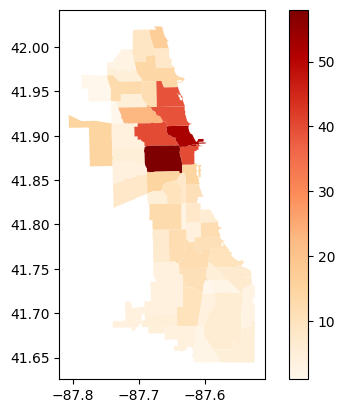

In [20]:
ax = df.plot(column="station_id", cmap="OrRd", legend=True)

In [21]:
plt.savefig("choropleth.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>